# Artistic Era Classifier (Ashryver Submodel)
This model is intended to classify the artistic era of a painting, in conjunction with the main Ashryver V2 model, as a fallback in case the Ashryver model is unable to identify the artist for the painting. The model recognizes ten key eras: **Renaissance, Baroque, Neoclassicism, Realism, Impressionism, Post-Impressionism, Cubism, Surrealism, Abstract Expressionism, Pop Art.**

In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from fastai.vision.all import * # fastai image classification
!pip install -Uqq duckduckgo_search==5.3.1b1
!pip install timm

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# Define the dataset folder explicitly so the name is stable across cells
painting_era_data = Path('painting_era_data')
print('painting_era_data =', painting_era_data)
painting_era_data.mkdir(exist_ok=True, parents=True)

painting_data = Path('painting_data')

painting_era_data = painting_era_data


In [3]:
import time
from duckduckgo_search import DDGS
from fastcore.all import *

# Define basic search images function for testing purposes only
def search_images(keywords, max_images=200):
    with DDGS() as ddgs:
        results = list(ddgs.images(keywords, max_results=max_images))
        time.sleep(2)
        return [r['image'] for r in results]

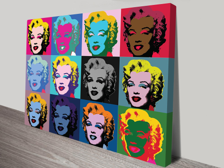

In [10]:
from fastdownload import download_url
from fastai.vision.all import *

# Test to see what kind of results we get
urls = search_images('pop art painting', max_images=1)
urls[0] 
 
dest = 'pop-art-painting.jpg'
download_url(urls[0], dest, show_progress=False)

im = Image.open(dest)
im.to_thumb(224,224) # show a preview of the image

In [12]:
# Renaissance, Baroque, Neoclassicism, Realism, Impressionism, Post-Impressionism, Cubism, Surrealism, Abstract Expressionism, Pop Art
# Define function to download painting images

def download_painting_images(era_names: list,
                           output_dir: Path = Path('painting_data'),
                           images_per_era: int = 400,
                           URL: str = None):
    """Reusable function to download images of paintings efficiently.

    URL: optional query string or template for searches. If provided and containing
    '{era_name}' it will be formatted per-artist, otherwise the literal string
    will be used for every artist. If omitted, a sensible default excluding
    common stock sites is used per-artist.
    """
    output_dir.mkdir(exist_ok=True, parents=True)

    for era_name in era_names:
        era_dir = output_dir / era_name
        era_dir.mkdir(exist_ok=True, parents=True)

        # Determine query to use for this era
        if URL is None:
            query = era_name + " painting -site:gettyimages.com -site:alamy.com -site:123rf.com"
        else:
            try:
                query = URL.format(era_name=era_name)
            except Exception:
                # If formatting fails, fall back to using the URL string as-is
                query = URL

        urls = search_images(query, max_images=images_per_era)

        download_images(era_dir, urls=urls)
        print(f"Downloaded {len(urls)} images for {era_name}")

# Pull down photos of the first 5 eras
eras_batch_1 = ['renaissance', 'baroque', 'neoclassicism', 'realism', 'impressionism']
download_painting_images(eras_batch_1)

Downloaded 324 images for renaissance
Downloaded 333 images for baroque
Downloaded 337 images for neoclassicism
Downloaded 327 images for realism
Downloaded 336 images for impressionism


In [13]:
eras_batch_2 = ['post-impressionism', 'cubism', 'surrealism', 'abstract expressionism', 'pop art']
download_painting_images(eras_batch_2)

Downloaded 312 images for post-impressionism
Downloaded 297 images for cubism
Downloaded 174 images for surrealism
Downloaded 346 images for abstract expressionism
Downloaded 296 images for pop art


In [21]:
# Check to see if any of the images failed to download properly
failed = verify_images(get_image_files(painting_data))
# verify_images returns a list (or L) of file paths that failed verification
for f in failed:
    try:
        Path(f).unlink()
    except Exception as e:
        print(f'Could not remove {f}: {e}')
print(f'Removed {len(failed)} failed images.')

Removed 10 failed images.


# Train the model

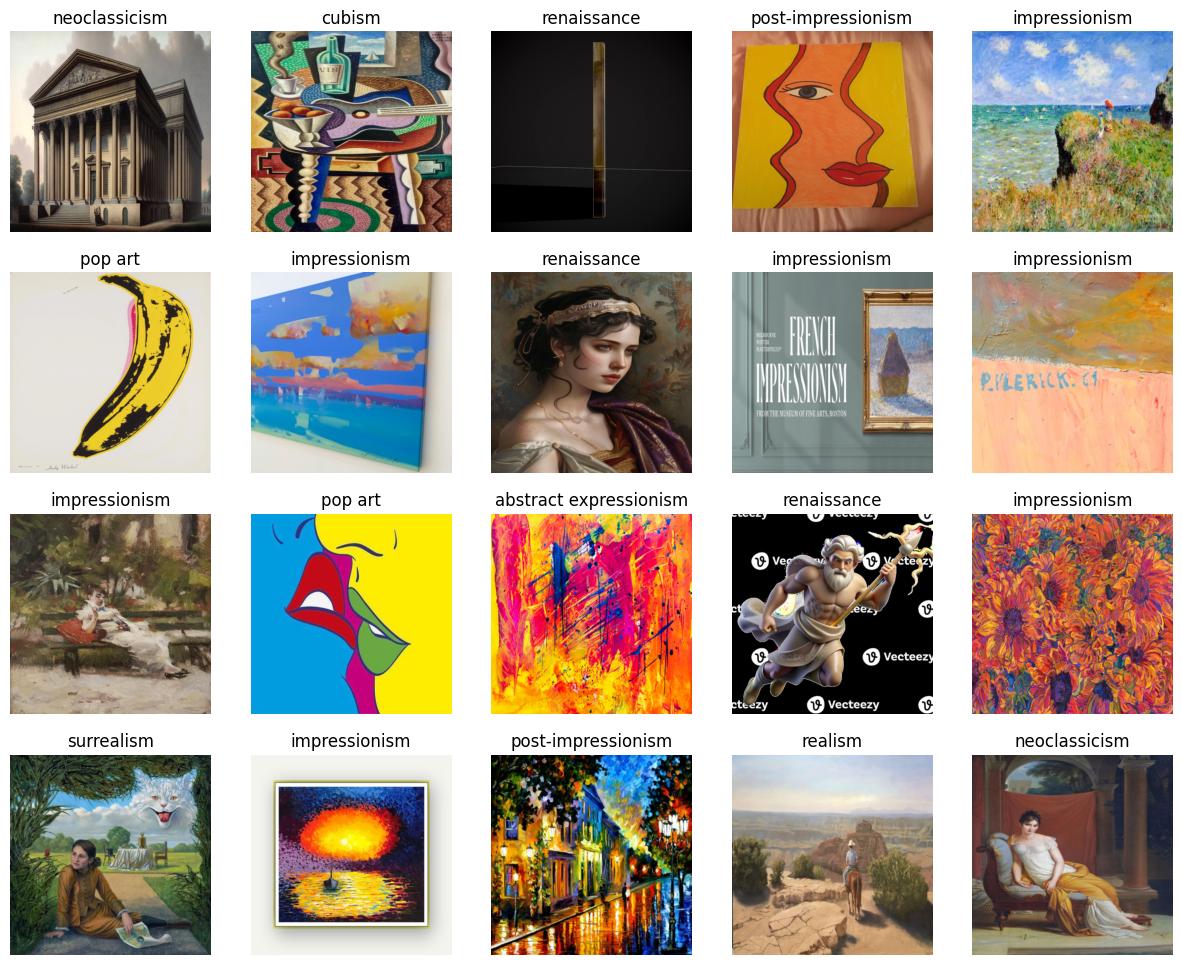

In [ ]:
# Dataset statistics: train items: 2081, valid items: 520

# Create the Datablock
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(448, method='squish')]
).dataloaders(painting_data, bs=32)

dls.show_batch(max_n=20) # show a sample of 20 images that the model will be trained upon

In [ ]:
# Going back to resnet50 for this one
import timm
learn = vision_learner(dls, resnet50 metrics=error_rate)
learn.fine_tune(4) # train the model for 4 epochs


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,2.256702,1.879104,0.496154,01:10


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,1.039485,1.458881,0.425000,01:40
1,0.823227,1.545665,0.417308,01:40
2,0.484950,1.440877,0.390385,01:40
3,0.282152,1.429877,0.375000,01:39


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

This is an Impressionist painting.
All Probabilities
abstract expressionism: 0.02%
baroque: 0.00%
cubism: 0.00%
impressionism: 98.64%
neoclassicism: 0.00%
pop art: 0.00%
post-impressionism: 1.32%
realism: 0.02%
renaissance: 0.00%
surrealism: 0.00%


<Axes: >

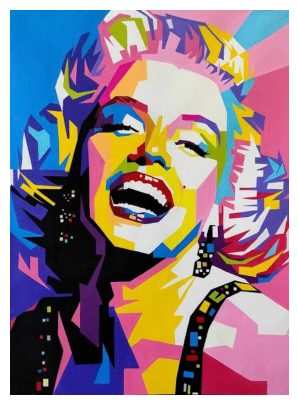

In [51]:
img = PILImage.create('painting-test-11.jpg')

# Map art movements to their proper descriptive adjectives with a dictionary
movement_to_adjective = {
    'renaissance': 'Renaissance',
    'baroque': 'Baroque',
    'neoclassicism': 'Neoclassical',
    'realism': 'Realistic',
    'impressionism': 'Impressionist',
    'post-impressionism': 'Post-Impressionist',
    'cubism': 'Cubist',
    'surrealism': 'Surrealist',
    'abstract expressionism': 'Abstract Expressionist',
    'pop art': 'Pop Art'
}

# Get the adjective, fallback to the label itself if it isn't in the dictionary
pred_adj = movement_to_adjective.get(pred_label, pred_label)

# Determine 'a' vs 'an' based on the first letter of the adjective
article = "an" if pred_adj[0].lower() in 'aeiou' else "a"

print(f"This is {article} {pred_adj} painting.\n============================\nAll Probabilities")
for class_name, probability in zip(learn.dls.vocab, all_probs):
    prob_val = probability * 100 # format to a percentage
    if class_name == pred_label:
            print(f"\033[1;32m{class_name}: {prob_val:.2f}%\033[0m") # output the predicted label as bold and green
    else:
        print(f"{class_name}: {prob_val:.2f}%")
show_image(img)

# Model incorrectly classified a pop-art Andy Warhol painting as impressionist

# Get some statistics on the model's performance

In [53]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42), # split 20% of the data off for validation
    get_y=parent_label,
    item_tfms=[Resize(448, method='squish')] # 224x224 image size for capturing more fine details
).dataloaders(painting_data, bs=32)

learn.dls = dls

print("train items:", len(learn.dls.train.dataset))
print("valid items:", len(learn.dls.valid.dataset))
print("vocab:", learn.dls.vocab)

def evaluate_model(learn, test_dl=None):
    """Get detailed metrics on how the classification model is performing"""
    if test_dl is None:
        test_dl = learn.dls.valid
    elif isinstance(test_dl, DataLoaders):
        test_dl = test_dl.valid

    if len(test_dl.dataset) == 0:
        raise ValueError("test_dl is empty; cannot evaluate model performance")

    preds, targs = learn.get_preds(dl=test_dl)
    if preds is None:
        raise RuntimeError("learn.get_preds() returned None. Ensure the learner and DataLoader are valid.")

    pred_classes = preds.argmax(dim=1)

    from sklearn.metrics import classification_report, confusion_matrix

    print("=== Classification Report ===")
    print(classification_report(targs, pred_classes, target_names=learn.dls.vocab))

    return confusion_matrix(targs, pred_classes)

evaluate_model(learn)

train items: 2081
valid items: 520
vocab: ['abstract expressionism', 'baroque', 'cubism', 'impressionism', 'neoclassicism', 'pop art', 'post-impressionism', 'realism', 'renaissance', 'surrealism']


=== Classification Report ===
                        precision    recall  f1-score   support

abstract expressionism       0.80      0.80      0.80        66
               baroque       0.63      0.52      0.57        69
                cubism       0.78      0.79      0.78        48
         impressionism       0.49      0.46      0.47        46
         neoclassicism       0.66      0.63      0.65        52
               pop art       0.78      0.74      0.76        43
    post-impressionism       0.45      0.52      0.48        56
               realism       0.54      0.57      0.55        60
           renaissance       0.55      0.55      0.55        56
            surrealism       0.45      0.58      0.51        24

              accuracy                           0.62       520
             macro avg       0.61      0.62      0.61       520
          weighted avg       0.62      0.62      0.62       520



array([[53,  1,  2,  2,  0,  0,  4,  2,  0,  2],
       [ 0, 36,  0,  1,  6,  1,  4,  1, 15,  5],
       [ 4,  0, 38,  2,  1,  2,  1,  0,  0,  0],
       [ 2,  3,  1, 21,  1,  1, 13,  4,  0,  0],
       [ 1,  2,  0,  3, 33,  0,  4,  4,  5,  0],
       [ 3,  1,  3,  0,  0, 32,  1,  1,  0,  2],
       [ 1,  2,  1, 11,  1,  2, 29,  6,  1,  2],
       [ 0,  1,  3,  3,  5,  2,  5, 34,  3,  4],
       [ 1, 10,  0,  0,  2,  1,  2,  7, 31,  2],
       [ 1,  1,  1,  0,  1,  0,  1,  4,  1, 14]])

In [55]:
# Export our crummy first model just for reference (it won't even be tracked by Git anyway, and we can just delete it later once we train better models)
learn.export('era_classifier_v1_timm_448x448_2601items_2026.pkl')